In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

from typing import Optional, Union

import scipy

from py_mods.src.SCF.plot_utilities import plot_map
from py_mods.src.external.DIRAC_ME import build_4c_one_Fock_from_h5, build_S_V_W_T_from_h5
from py_mods.src.algebra.quaternion import quaternion_to_matrix

In [ ]:
checkpoint_files = ['files/H_checkpoint.h5', 'files/He_checkpoint.h5', 'files/Ne_checkpoint.h5']
for checkpoint_file in checkpoint_files:
    F_0 = build_4c_one_Fock_from_h5(checkpoint_file)

    with h5py.File(checkpoint_file, "r") as f:
        fockarra = np.asarray(f["result/operators/ao_matrices/ONEFOCK"][()])
        overlap = np.asarray(f["result/operators/ao_matrices/OVERLAP TFFT"][()])

    n_bas = int((np.sqrt(1 + 8 * len(overlap)) - 1) / 2)

    focsquare = fockarra.reshape(4,n_bas,n_bas) # or manually, but this is convenient
    f0, f1, f2, f3 = focsquare[0], focsquare[1], focsquare[2], focsquare[3]
    Qf = quaternion_to_matrix(f0,f1,f2,f3)

    print(f"For Checkpoint file {checkpoint_file}, extracted F == recostructed F: {np.allclose(Qf, F_0)}")

34
For Checkpoint file files/H_checkpoint.h5, extracted F == recostructed F: True
34
For Checkpoint file files/He_checkpoint.h5, extracted F == recostructed F: True
119
For Checkpoint file files/Ne_checkpoint.h5, extracted F == recostructed F: True


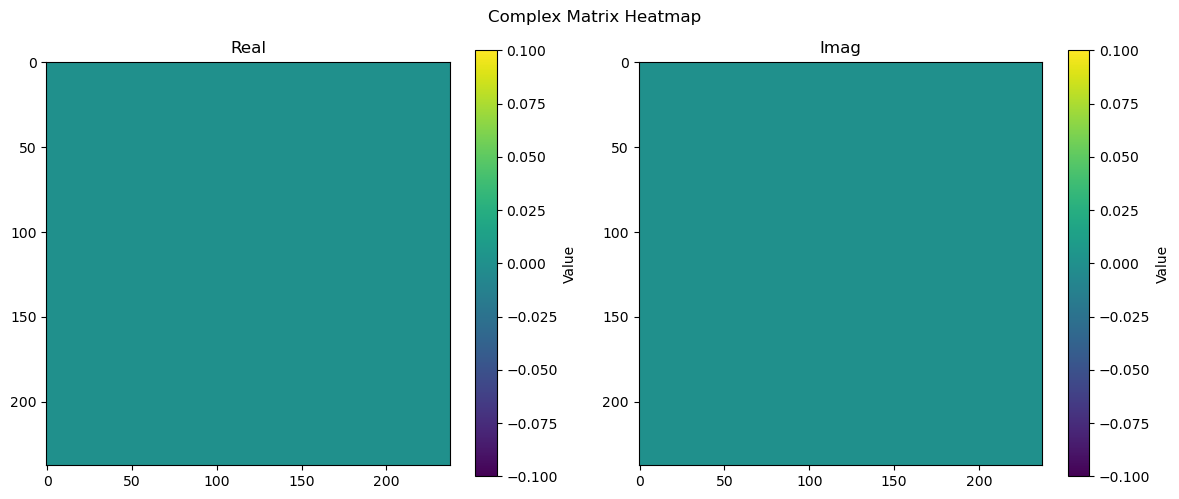

In [3]:
plot_map(Qf-F_0)

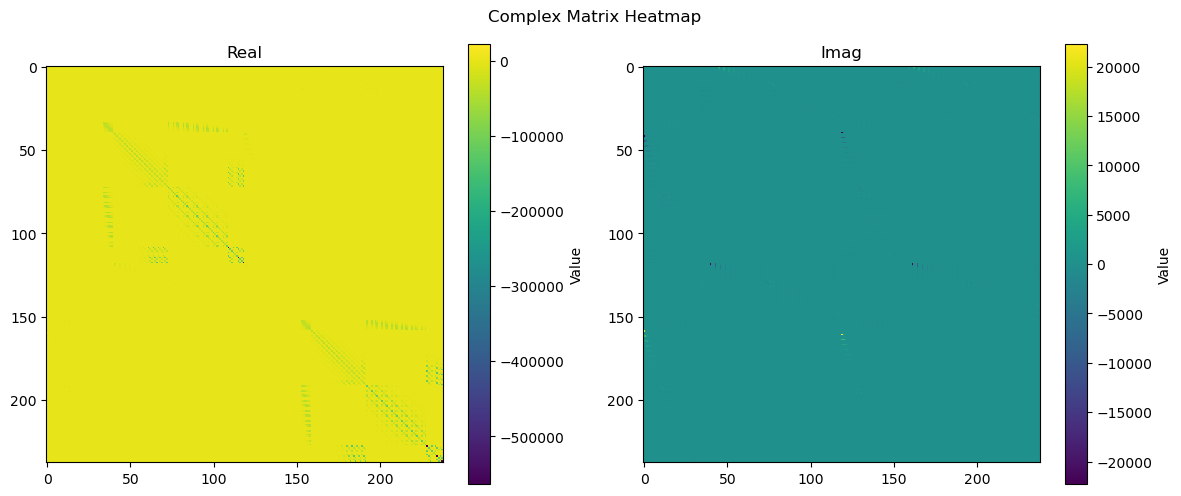

In [4]:
plot_map(F_0)